## Imports

In [95]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib as mpl
import scipy.io as sio

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.io import loadmat
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import r2_score

import sys
sys.path.insert(1, '../SCA')
sys.path.insert(2, '../data')
from architecture import SCA_autoencoder
from model import SCA
from util import loss_func,create_W

## Importing and Initially Visualizing Data

In [96]:
monkeyB_reaching = loadmat('../data/monkeyB_reaching.mat')
data = monkeyB_reaching['data']
print(f"data shape: {data.shape}")
# 8 conditions, 124 neurons, 3003 timesteps

data shape: (8, 124, 3003)


## Pre-processing

In [114]:
data_downsamp = data[:,:,np.arange(0,data.shape[2],10)]

C,N,T = data_downsamp.shape
data_concat = data_downsamp.swapaxes(0,1).reshape([N,C*T])

Time_mask = np.tile(np.arange(T),(1,C)).T.flatten()

# define the times we want to use for sca/pca
# target on: 20
# move on:   77
# return:    200

trainTimes = np.arange(20,230)
trainMask = np.isin(Time_mask,trainTimes)

# --- 1) mean-center across different conditions --- #

mean_ = np.mean(data_downsamp,axis=0)[None,:,:]
data_new = data_downsamp - mean_
data_concat_mean_sub = data_new.swapaxes(0,1).reshape([N,C*T])

# --- 2) soft-normalize --- #

range_ = np.ptp(data_concat,axis=1)[:,None]
data_final = data_concat_mean_sub / (range_+5)
data_final = data_final.T

Text(0.5, 1.0, 'Post-processing')

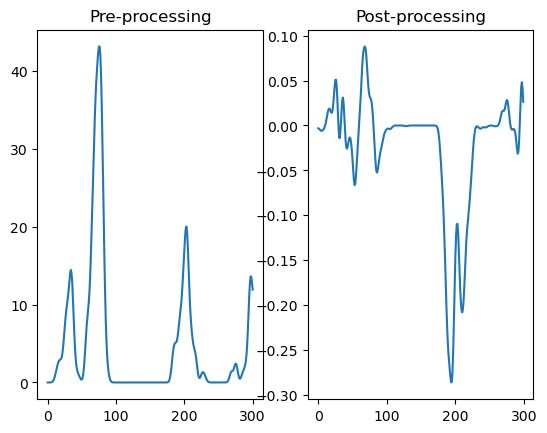

In [115]:
fig,ax = plt.subplots(1,2)
ax[0].plot(data_downsamp[0,5,:])
ax[1].plot(data_final[:300,5])
ax[0].set_title('Pre-processing')
ax[1].set_title('Post-processing')

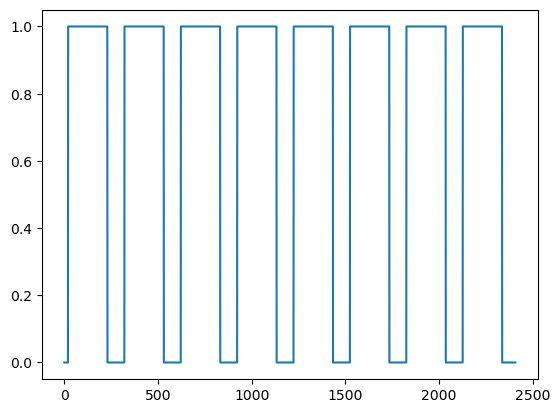

In [117]:
plt.plot(trainMask[:])

In [118]:
num_components = 8
X = data_final
SCA_0 = SCA(torch.tensor(X[trainMask,:],dtype=torch.float),num_components)

init recon: 945.9934692382812
init sparse: 94.5993423461914
init orth: 94.59934997558594
lam_sparse: 0.032367486506700516
lam_orth: 168.9274139404297


100%|██████████| 3000/3000 [00:11<00:00, 254.21it/s]


Text(0, 0.5, 'loss')

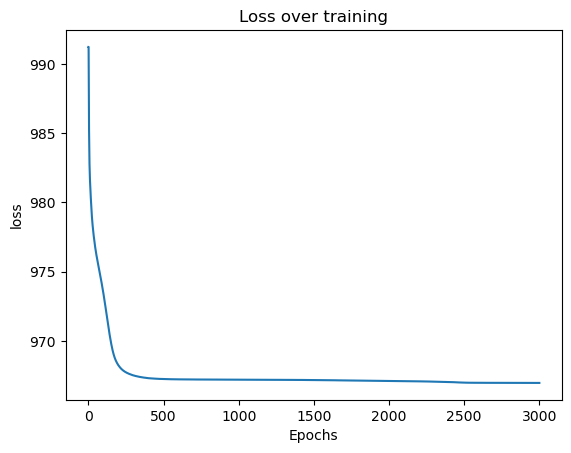

In [119]:
fig,ax = plt.subplots()
ax.plot(SCA_0['losses'].detach().numpy())
ax.set_title('Loss over training')
ax.set_xlabel('Epochs')
ax.set_ylabel('loss')

## Alternatively, fitting data via WPCA

In [121]:
latent_sca = SCA_0['latent'].detach().numpy()
out_sca = SCA_0['out'].detach().numpy()

W_ = create_W(torch.tensor(X[trainMask,:])).numpy()
W_full = create_W(torch.tensor(X)).numpy()
svd = TruncatedSVD(num_components)
svd.fit(W_@X[trainMask,:])
U = svd.components_.T
V = svd.components_

latent_wpca = X[trainMask]@U
out_wpca = latent_wpca@V

In [122]:
new_sca = SCA_autoencoder(N,num_components,torch.rand((N,num_components)).T)
new_sca.load_state_dict(SCA_0['autoencoder_state_dict'])

latent_sca_full,out_sca_full = new_sca(torch.tensor(X,dtype=torch.float))
latent_sca_full = latent_sca_full.detach().numpy()
out_sca_full = out_sca_full.detach().numpy()

## Look at orthogonality of U and V

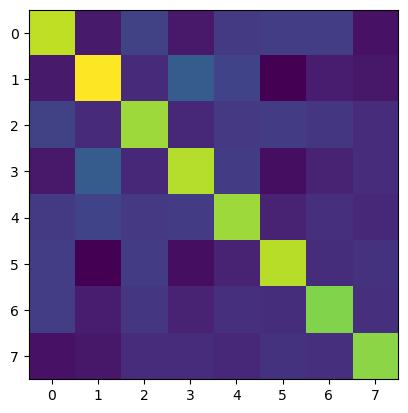

In [123]:
U_sca = new_sca.U.weight.detach().numpy()
V_sca = new_sca.V.weight.detach().numpy()

plt.imshow(U_sca@U_sca.T)

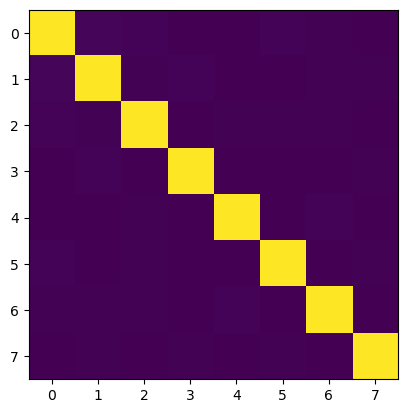

In [124]:
plt.imshow(V_sca.T@V_sca)

## Compare $R^2$ of the two approaches

In [125]:
r2_sca = r2_score(X[trainMask], out_sca, sample_weight=np.diag(W_), multioutput = 'variance_weighted')
r2_wpca = r2_score(X[trainMask], out_wpca, sample_weight=np.diag(W_), multioutput = 'variance_weighted')

print(f"r2 of SCA: {r2_sca}")
print(f"r2 of WPCA: {r2_wpca}")

r2 of SCA: 0.6316436694096382
r2 of WPCA: 0.6379122771741547


## Reorder by cross-condition variance

In [126]:
rs_sca_latent = np.reshape(latent_sca_full,(-1,C,num_components),order='F')
sca_var = np.var(rs_sca_latent,axis=1)
max_occ = np.argmax(sca_var,axis=0)
sca_order = np.argsort(max_occ)
ordered_sca = rs_sca_latent[:,:,sca_order]

rs_wpca_latent = np.reshape(latent_wpca,(-1,C,num_components),order='F')
sca_var = np.var(rs_wpca_latent,axis=1)
max_occ = np.argmax(sca_var,axis=0)
wpca_order = np.argsort(max_occ)
ordered_sca = rs_wpca_latent[:,:,sca_order]

target_idx = 20
move_idx = 77
return_idx = 200

In [127]:
cMap  = ['#5e0044', '#6f144e', '#812858', '#933c62', '#a5506d', '#b76477', '#c97881', '#db8c8c']

In [128]:
# range for y axis
yRange = [-1.8,1.8]

fig = make_subplots(rows=num_components,cols = 1,shared_xaxes = True,vertical_spacing = 0)

for ii in range(num_components):

    for jj in range(C):
        latTrace = go.Scatter(y = rs_sca_latent[:,jj,ii], line = go.scatter.Line(color = cMap[jj],width = 2.5),showlegend = False)
        fig.add_trace(latTrace,row = ii+1,col=1)

    # mark important task events
    fig.add_vline(x = target_idx,row = ii+1,col = 1, line_color = 'black')
    fig.add_vline(x = move_idx,row = ii+1,col = 1, line_color = 'black')
    fig.add_vline(x = return_idx,row = ii+1,col = 1, line_color = 'black')

    # add a vertical line for scale
    scaleLine = go.Scatter(x = [0,0],y = [-1,1],showlegend = False,mode = 'lines',
                            line = go.scatter.Line(color = 'black',width = 5))
    fig.add_trace(scaleLine,row = ii+1,col = 1)


# clean up
fig.update_layout(height = 2000,width =600,title = 'SCA',title_font_color = 'black',
                  paper_bgcolor = 'white',
                  plot_bgcolor = 'white')
fig.update_yaxes(showgrid = False,zeroline = False,visible = False,range = yRange)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,visible = False)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,
                 ticks = 'outside',tickvals = [0,50],ticktext = ['0','500'],visible = True,row = num_components,col = 1)

fig.show()

In [129]:
# range for y axis
yRange = [-1.8,1.8]

fig = make_subplots(rows=num_components,cols = 1,shared_xaxes = True,vertical_spacing = 0)

for ii in range(num_components):

    for jj in range(C):
        latTrace = go.Scatter(y = rs_wpca_latent[:,jj,ii], line = go.scatter.Line(color = cMap[jj],width = 2.5),showlegend = False)
        fig.add_trace(latTrace,row = ii+1,col=1)

    # mark important task events
    fig.add_vline(x = target_idx,row = ii+1,col = 1, line_color = 'black')
    fig.add_vline(x = move_idx,row = ii+1,col = 1, line_color = 'black')
    fig.add_vline(x = return_idx,row = ii+1,col = 1, line_color = 'black')

    # add a vertical line for scale
    scaleLine = go.Scatter(x = [0,0],y = [-1,1],showlegend = False,mode = 'lines',
                            line = go.scatter.Line(color = 'black',width = 5))
    fig.add_trace(scaleLine,row = ii+1,col = 1)


# clean up
fig.update_layout(height = 2000,width =600,title = 'PCA',title_font_color = 'black',
                  paper_bgcolor = 'white',
                  plot_bgcolor = 'white')
fig.update_yaxes(showgrid = False,zeroline = False,visible = False,range = yRange)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,visible = False)
fig.update_xaxes(color = 'black',showgrid = False,zeroline = False,
                 ticks = 'outside',tickvals = [0,50],ticktext = ['0','500'],visible = True,row = num_components,col = 1)

fig.show()